# 03 · Forecast model, rolling-origin backtest and risk scoring
LightGBM, one global model across SKUs, direct multi-horizon (one row per SKU × origin × horizon). Features: lags, rolling statistics, same-week-last-year, calendar and planned promotion days. **Every demand feature uses only weeks up to the origin** (see `tests/test_core.py::test_features_do_not_see_the_future`).

In [1]:
import sys, json, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20); pd.set_option('display.max_colwidth', 80)

In [2]:
from src import pipeline, config as C
from src.features import Panel, FEATURES, training_rows, rows_for_origin
from src import forecast as F
P = Panel(pipeline.run(save=False, verbose=False)['weekly'])
print(len(FEATURES), 'features:', FEATURES)

22 features: ['h', 'lag0', 'lag1', 'lag2', 'lag3', 'rm4', 'rm8', 'rm13', 'rm26', 'rstd8', 'exp_mean', 'sn', 'sn3', 'sn_adj', 'yoy_level', 'promo_days_T', 'holiday_days_T', 'promo_days_T_ly', 'woy_T', 'month_T', 'category_code', 'log_price']


## One fold, step by step
Train only on weeks ≤ origin, forecast the next 8 weeks, compare with the baseline.

In [3]:
o = F.backtest_origins(99)[-1]
train = training_rows(P, o)
print('origin', P.week_date(o).date(), '| training rows', len(train), '| max target week used', P.week_date(int(train.target_idx.max())).date())
m = F.fit_model(train)
test = rows_for_origin(P, o); test['model'] = F.predict(m, test)
test['baseline'] = np.concatenate([F.seasonal_naive(P, o)[h] for h in range(1, 9)])
print('model WAPE %.3f vs baseline %.3f' % (F.wape(test.y, test.model), F.wape(test.y, test.baseline)))

origin 2025-09-29 | training rows 33800 | max target week used 2025-09-29


model WAPE 0.079 vs baseline 0.110


## Full rolling-origin backtest (from `run_pipeline.py`)

In [4]:
M = json.loads((ROOT/'outputs/metrics.json').read_text())
pd.Series(M['backtest']).to_frame('value')

,value
model_wape,0.086537
baseline_wape,0.105030
model_bias,-0.009393
baseline_bias,0.002616
model_mape,0.105452
baseline_mape,0.133051
n_folds,10.000000
n_forecasts,4000.000000
wape_improvement_pct,17.608074


In [5]:
pd.read_csv(ROOT/'outputs/backtest_by_fold.csv').round(3)

,fold,week_from,week_to,model_wape,baseline_wape
0,55,2025-01-27,2025-03-17,0.087,0.096
1,59,2025-02-24,2025-04-14,0.081,0.096
2,63,2025-03-24,2025-05-12,0.080,0.100
3,67,2025-04-21,2025-06-09,0.078,0.096
4,71,2025-05-19,2025-07-07,0.087,0.100
5,75,2025-06-16,2025-08-04,0.100,0.110
6,79,2025-07-14,2025-09-01,0.095,0.117
7,83,2025-08-11,2025-09-29,0.093,0.121
8,87,2025-09-08,2025-10-27,0.088,0.114
9,91,2025-10-06,2025-11-24,0.079,0.110


In [6]:
pd.read_csv(ROOT/'outputs/backtest_by_horizon.csv').round(3)

,h,model_wape,baseline_wape
0,1,0.077,0.105
1,2,0.082,0.103
2,3,0.093,0.106
3,4,0.083,0.104
4,5,0.080,0.104
5,6,0.083,0.103
6,7,0.099,0.107
7,8,0.094,0.108


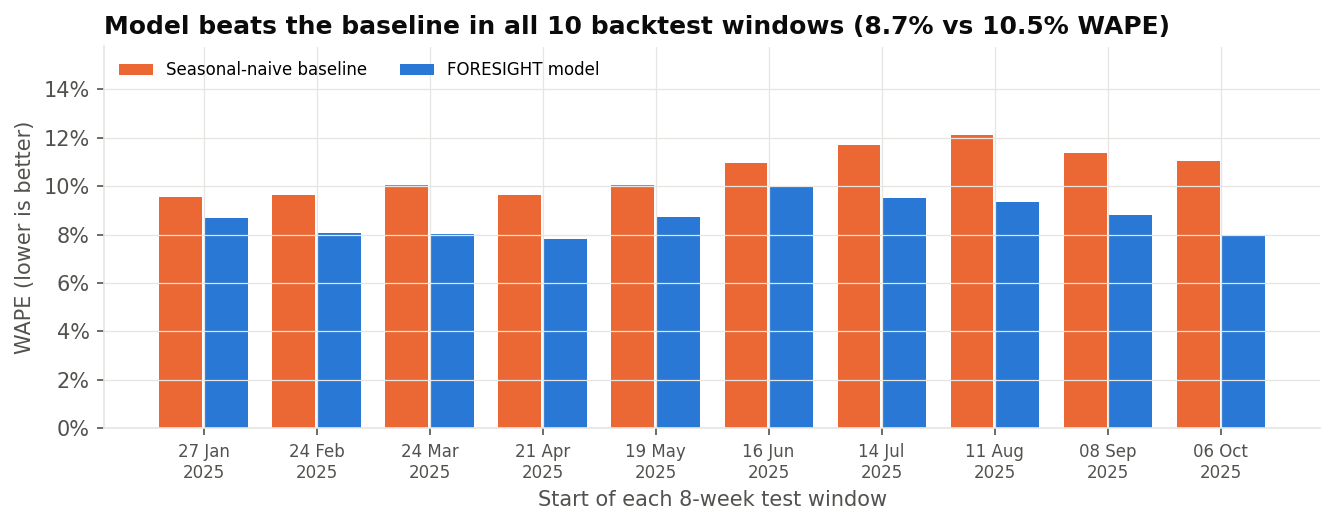

Hold-out after the stock date: {'weeks': 4, 'model_wape': 0.08657945204853194, 'baseline_wape': 0.12418150488225158}


In [7]:
display(Image(str(ROOT/'reports/figures/08_backtest_wape_by_fold.png')))
print('Hold-out after the stock date:', M['holdout_after_as_of'])

**Decision:** the model beats seasonal-naive in every fold and on the untouched weeks after the stock date, with negligible bias, so it ships. The 80% range comes from the empirical spread of backtest errors at each horizon.

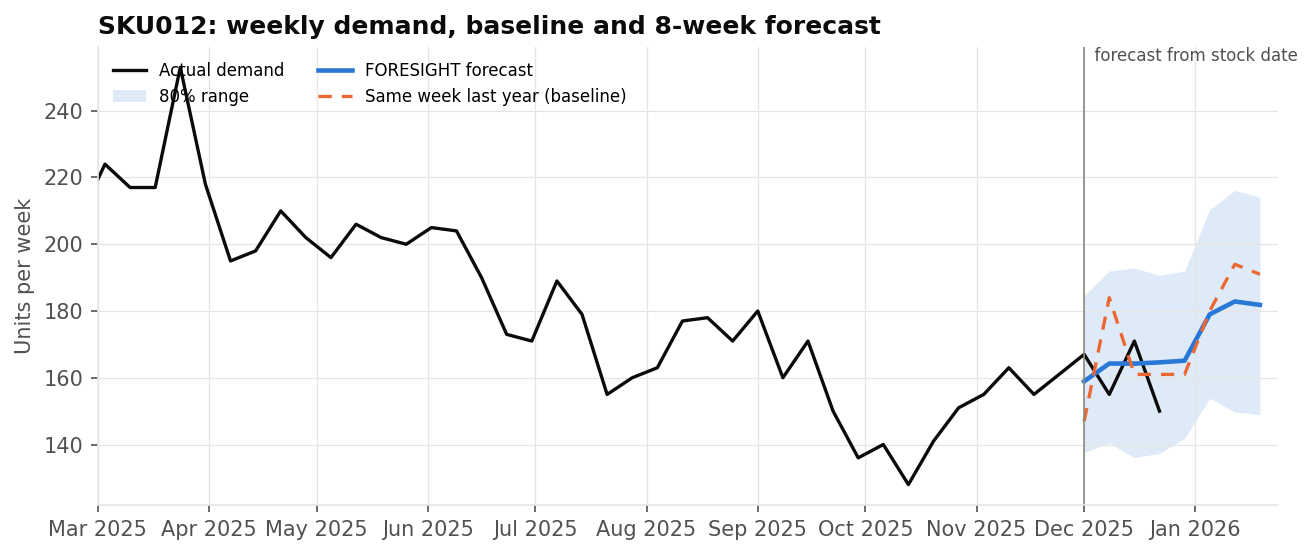

,h,lo_ratio,hi_ratio
0,1,0.866,1.162
1,2,0.855,1.169
2,3,0.829,1.175
3,4,0.834,1.158
4,5,0.859,1.163
5,6,0.860,1.175
6,7,0.819,1.182
7,8,0.819,1.178


In [8]:
display(Image(str(ROOT/'reports/figures/07_forecast_example.png')))
pd.DataFrame(M['interval_ratios']).round(3)

## Risk scoring (Section 08)
Stockout risk = P(lead-time demand > on-hand + on-order − safety stock); flagged above 10% (90% service level).  
Overstock risk = P(8-week demand < on-hand − safety stock); flagged above 50%.

In [9]:
r = pd.read_csv(ROOT/'outputs/risk_scores.csv')
print(r.quadrant.value_counts().to_dict())
r[r.quadrant!='Healthy'][['sku_id','category','quadrant','stockout_risk','overstock_risk','days_of_cover','suggested_order_units','value_at_stake_inr']]

{'Healthy': 39, 'Reorder now': 7, 'Markdown / clear': 4}


,sku_id,category,quadrant,stockout_risk,overstock_risk,days_of_cover,suggested_order_units,value_at_stake_inr
0,SKU012,Home Decor,Reorder now,1.0000,0.0000,4.4,1270,11007844.98
1,SKU031,Furniture,Reorder now,1.0000,0.0000,7.6,874,7372920.88
2,SKU017,Home Decor,Reorder now,1.0000,0.0000,9.4,710,5097239.09
3,SKU040,Storage,Reorder now,1.0000,0.0000,6.6,750,1749171.90
4,SKU034,Lighting,Reorder now,0.1532,0.0000,7.4,937,1369801.02
5,SKU025,Storage,Markdown / clear,0.0000,1.0000,472.6,0,1149908.73
6,SKU020,Storage,Markdown / clear,0.0000,0.9999,106.6,0,1080285.97
7,SKU023,Kitchen,Reorder now,0.1912,0.0000,15.6,582,765444.79
8,SKU011,Furniture,Markdown / clear,0.0000,1.0000,406.1,0,744184.86
9,SKU010,Storage,Reorder now,0.9999,0.0000,10.0,729,468645.47


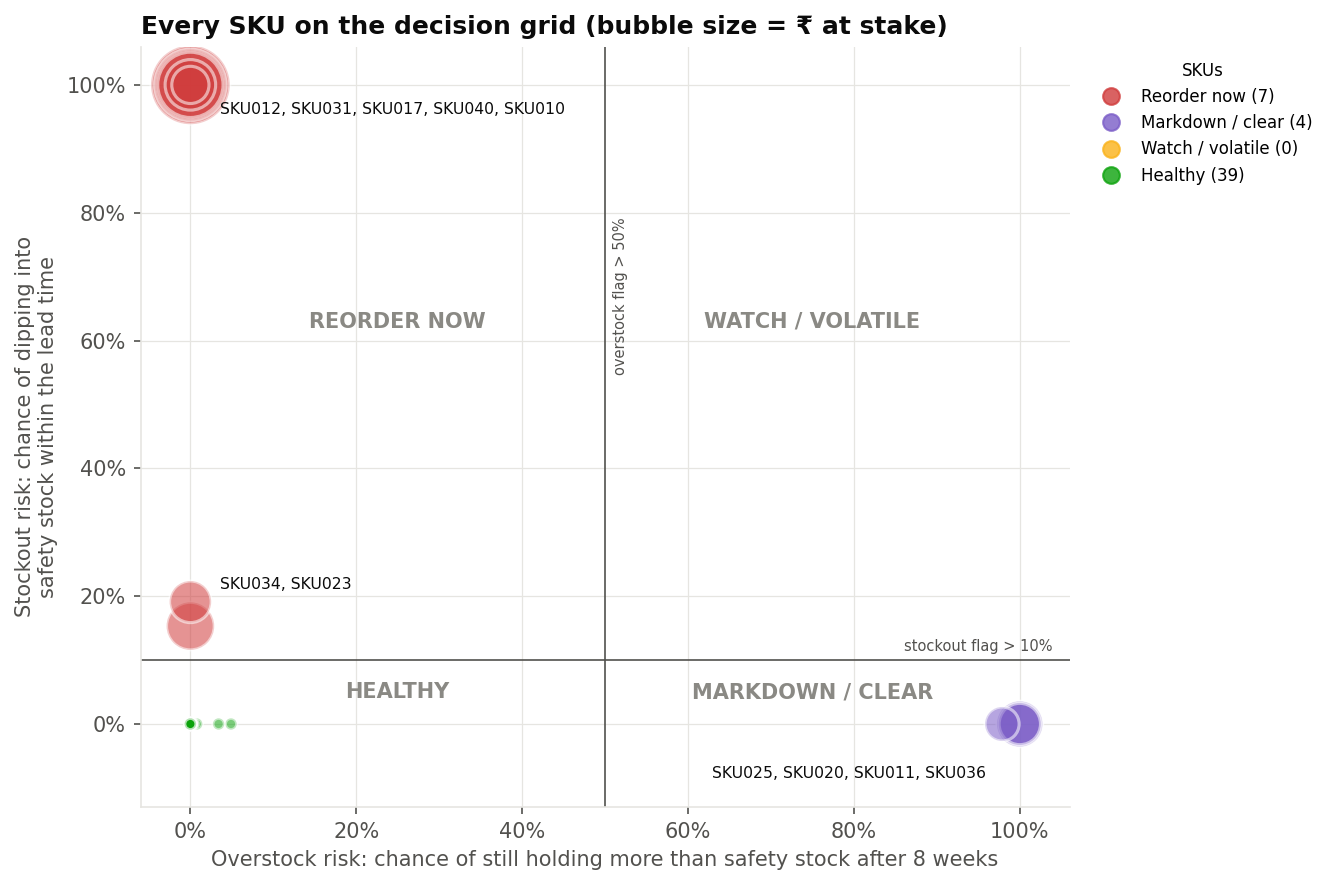

In [10]:
display(Image(str(ROOT/'reports/figures/09_decision_grid.png')))